# Dataset Exploration

In [1]:
import sys

# Load github repo
!git clone https://github.com/erezpoliak/AnimalClassifier

# Remove unnecessary LICENSE.md from dataset
!rm /content/AnimalClassifier/animal_data/LICENSE.md

sys.path.append('/content/AnimalClassifier/EX4 - Project')
!ls 'AnimalClassifier/animal_data'

DATA_PATH = '/content/AnimalClassifier/animal_data'

Cloning into 'AnimalClassifier'...
remote: Enumerating objects: 2040, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 2040 (delta 36), reused 56 (delta 14), pack-reused 1962 (from 2)
Receiving objects: 100% (2040/2040), 43.94 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (37/37), done.
Bear  Cat  Deer  Dolphin   Giraffe  Kangaroo  Panda  Zebra
Bird  Cow  Dog	 Elephant  Horse    Lion      Tiger


In [2]:
# Checking for corrupted images
from dataset_util import check_corrupted_images

corrupted = check_corrupted_images(DATA_PATH)
print(f'Number of corrupted images: {len(corrupted)}')

Number of corrupted images: 0


In [3]:
# Basic info on data
from dataset_util import display_basic_info
from torchvision import datasets, transforms

dataset = datasets.ImageFolder(root=DATA_PATH, transform = transforms.ToTensor())
display_basic_info(dataset)

Number of images: 1944
Number of classes: 15
Classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


In [4]:
# Checking class distribution
from dataset_util import display_class_distribution

display_class_distribution(dataset)

Bear: 125
Bird: 137
Cat: 123
Cow: 131
Deer: 127
Dog: 122
Dolphin: 129
Elephant: 133
Giraffe: 129
Horse: 130
Kangaroo: 126
Lion: 131
Panda: 135
Tiger: 129
Zebra: 137


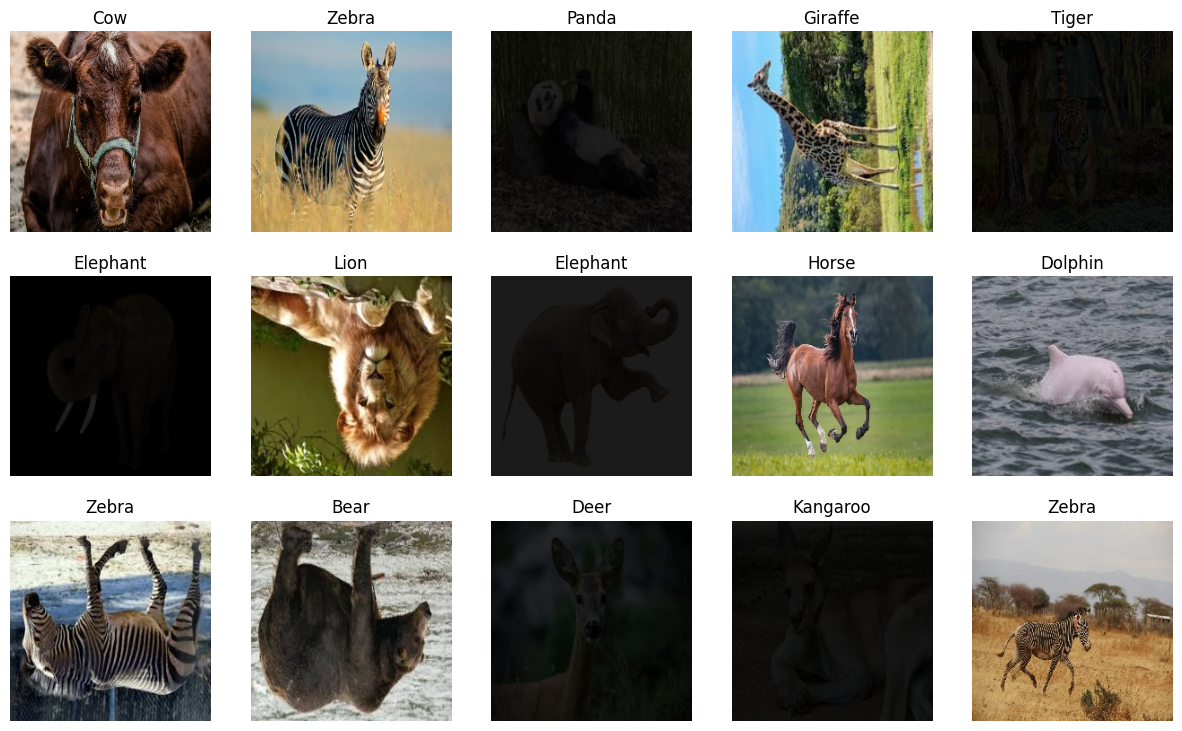

In [5]:
# Few image samples
from dataset_util import display_image_samples

display_image_samples(dataset)

# Experiments

In [6]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
# Normalize data

from dataset_util import dataset_split, calculate_normalization_stats, get_normalized_transforms

# Load with basic transforms
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
full_dataset = datasets.ImageFolder(DATA_PATH, transform=basic_transform)

# Split 70/15/15
train_dataset, val_dataset, test_dataset = dataset_split(full_dataset, 0.7, 0.15)

# Calculate stats from train
mean, std = calculate_normalization_stats(train_dataset)

train_transform = get_normalized_transforms(mean, std, augment=False)
val_test_transform = get_normalized_transforms(mean, std, augment=False)

train_full = datasets.ImageFolder(DATA_PATH, transform=train_transform)
val_full = datasets.ImageFolder(DATA_PATH, transform=val_test_transform)
test_full = datasets.ImageFolder(DATA_PATH, transform=val_test_transform)

train_ds, _, _ = dataset_split(train_full, 0.7, 0.15)
_, val_ds, _ = dataset_split(val_full, 0.7, 0.15)
_, _, test_ds = dataset_split(test_full, 0.7, 0.15)

### Experiment 1 - Shallow vs Deep

In [10]:
from CustomCNN import CustomCNN
from model_util import train

BATCH_SIZE = 32
LR = 0.001
EPOCHS = 50
PATIENCE = 10

architecutres = {
    'Shallow':{
        'conv_layers': [32, 64],
        'fc_layers': [128]
    },
    'Medium':{
        'conv_layers': [64, 128, 256],
        'fc_layers': [256, 128]
    },
    'Deeper':{
        'conv_layers': [32, 64, 128, 256],
        'fc_layers': [512, 256]
    }
}

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

for config in architecutres:
  conv = architecutres[config]['conv_layers']
  fc = architecutres[config]['fc_layers']

  print(f'Architecture {config} - conv layers {conv}, fc layers {fc}')

  model = CustomCNN(conv, fc).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=LR)
  train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
  print()

Architecture Shallow - conv layers [32, 64], fc layers [128]
Epoch 1/50 - Train Loss: 16.2449 - Train Acc: 0.1184 - Val Loss: 2.5281 - Val Acc: 0.1993
Epoch 5/50 - Train Loss: 0.6253 - Train Acc: 0.7993 - Val Loss: 1.0437 - Val Acc: 0.6701
Epoch 10/50 - Train Loss: 0.5423 - Train Acc: 0.8228 - Val Loss: 1.0783 - Val Acc: 0.6942
Epoch 15/50 - Train Loss: 0.5799 - Train Acc: 0.8132 - Val Loss: 1.1392 - Val Acc: 0.6907
Early stopping at epoch 16

Architecture Medium - conv layers [64, 128, 256], fc layers [256, 128]
Epoch 1/50 - Train Loss: 12.0247 - Train Acc: 0.1037 - Val Loss: 2.5222 - Val Acc: 0.1615
Epoch 5/50 - Train Loss: 0.7157 - Train Acc: 0.7779 - Val Loss: 1.0873 - Val Acc: 0.6907
Epoch 10/50 - Train Loss: 0.4913 - Train Acc: 0.8456 - Val Loss: 1.2146 - Val Acc: 0.7182
Epoch 15/50 - Train Loss: 0.4312 - Train Acc: 0.8676 - Val Loss: 1.2969 - Val Acc: 0.7595
Epoch 20/50 - Train Loss: 0.2152 - Train Acc: 0.9404 - Val Loss: 1.2637 - Val Acc: 0.8144
Epoch 25/50 - Train Loss: 0.1368

Insights:

- The Shallow network trained quickly, but achieved the lowest validation accuracy (~0.69), showing limited learning capacity.

- The Medium network reached higher validation accuracy (~0.82) but showed clear overfitting, with a noticeable gap between training and validation loss.

- The Deeper network achieved the highest validation accuracy (~0.88), and also displayed major overfitting, indicating it has the greatest capacity to learn complex patterns.

- We can conclude there is a trade-off, the deeper the network the more capacity to learn, but also more risk for overfitting

It seems like it would be best to proceed with the Deeper architecture

### Experiment 2 - Optimizer Comparison

In [12]:
architecure = architecutres['Deeper']
conv = architecure['conv_layers']
fc = architecure['fc_layers']

model = CustomCNN(conv, fc).to(device)

configs = {
    'SGD': torch.optim.SGD(model.parameters(), lr=0.001),
    'SGD - Momentum': torch.optim.SGD(model.parameters(), lr = 0.001, momentum = 0.9),
    'Adam': torch.optim.Adam(model.parameters(), lr=0.001),
}

for config in configs:
  optimizer = configs[config]
  print(f'Optimizer {config}')
  _,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
  print()

Optimizer SGD
Epoch 1/50 - Train Loss: 5.1010 - Train Acc: 0.1287 - Val Loss: 2.5443 - Val Acc: 0.2302
Epoch 5/50 - Train Loss: 1.7501 - Train Acc: 0.4515 - Val Loss: 1.7382 - Val Acc: 0.4605
Epoch 10/50 - Train Loss: 1.1568 - Train Acc: 0.6699 - Val Loss: 1.3796 - Val Acc: 0.6082
Epoch 15/50 - Train Loss: 0.8289 - Train Acc: 0.7676 - Val Loss: 1.1559 - Val Acc: 0.6495
Epoch 20/50 - Train Loss: 0.6258 - Train Acc: 0.8324 - Val Loss: 1.0610 - Val Acc: 0.6907
Epoch 25/50 - Train Loss: 0.5226 - Train Acc: 0.8529 - Val Loss: 1.0296 - Val Acc: 0.7045
Epoch 30/50 - Train Loss: 0.4596 - Train Acc: 0.8706 - Val Loss: 1.0716 - Val Acc: 0.7079
Epoch 35/50 - Train Loss: 0.4081 - Train Acc: 0.8846 - Val Loss: 0.9267 - Val Acc: 0.7629
Early stopping at epoch 37

Optimizer SGD - Momentum
Epoch 1/50 - Train Loss: 2.3190 - Train Acc: 0.4103 - Val Loss: 2.4330 - Val Acc: 0.2680
Epoch 5/50 - Train Loss: 1.2415 - Train Acc: 0.5993 - Val Loss: 1.1094 - Val Acc: 0.6564
Epoch 10/50 - Train Loss: 0.6087 - Tr

Insights:

- SGD: Converges slowly, reaching Val Acc ~0.76 after ~40 epochs. Stable but gradual improvement, limited by slow start.

- SGD + Momentum: Faster convergence, reaches similar Val Acc ~0.78 by ~20 epochs. Momentum improves speed and stability, reducing oscillations.

- Adam: Achieved best accuracy, fast convergence similar to SGD + momentum, reaching Val Acc ~0.9 by ~20 epochs. Adaptive learning rates give quick, stable learning, though overfitting can appear earlier.

Adam will the pick to move on with.

### Experiment 3 - Learning Rate And Batch Size

In [14]:
architecure = architecutres['Deeper']
conv = architecure['conv_layers']
fc = architecure['fc_layers']

lrs = [0.001, 0.0001]
batch_sizes = [32, 64]

for lr in lrs:
  for batch_size in batch_sizes:
    print(f'Batch Size {batch_size}, LR {lr}')
    model = CustomCNN(conv, fc).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    _,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
    print()

Batch Size 32, LR 0.001
Epoch 1/50 - Train Loss: 8.2711 - Train Acc: 0.1235 - Val Loss: 2.3878 - Val Acc: 0.2165
Epoch 5/50 - Train Loss: 0.8420 - Train Acc: 0.7390 - Val Loss: 0.8711 - Val Acc: 0.7629
Epoch 10/50 - Train Loss: 0.2611 - Train Acc: 0.9287 - Val Loss: 0.8493 - Val Acc: 0.8454
Epoch 15/50 - Train Loss: 0.2087 - Train Acc: 0.9441 - Val Loss: 1.0443 - Val Acc: 0.8557
Epoch 20/50 - Train Loss: 0.0085 - Train Acc: 0.9993 - Val Loss: 0.7946 - Val Acc: 0.8969
Epoch 25/50 - Train Loss: 0.0002 - Train Acc: 1.0000 - Val Loss: 0.8389 - Val Acc: 0.8935
Epoch 30/50 - Train Loss: 0.0001 - Train Acc: 1.0000 - Val Loss: 0.8650 - Val Acc: 0.8935
Early stopping at epoch 31

Batch Size 64, LR 0.001
Epoch 1/50 - Train Loss: 12.6142 - Train Acc: 0.0890 - Val Loss: 2.6715 - Val Acc: 0.1409
Epoch 5/50 - Train Loss: 1.5421 - Train Acc: 0.5184 - Val Loss: 1.3548 - Val Acc: 0.5808
Epoch 10/50 - Train Loss: 0.6685 - Train Acc: 0.7831 - Val Loss: 1.0255 - Val Acc: 0.7251
Epoch 15/50 - Train Loss: 0

Insights:

- There is severe overfitting issue with all configurations, with val loss gaps of 0.6-0.8 and train accuracy ~100%.
- LR trade-off: LR (0.0001) allowed less severe overfitting, at the cost of worse performance on validation accuracy.
- The best configuration overall was: BS 32, LR 0.001 as it achievied the best val acc (~0.89) and converged the fastest.

Conclusion: Strong regularization techniques are required

### Experiment 4 - Batch Normalization

In [15]:
BATCH_SIZE = 32
LR = 0.001

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print('Batch Normalization')
model = CustomCNN(conv, fc, batch_norm = True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
_,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

print('No batch normalization')
model = CustomCNN(conv, fc, batch_norm = False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
_,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)

Batch Normalization
Epoch 1/50 - Train Loss: 133.2074 - Train Acc: 0.1625 - Val Loss: 23.8906 - Val Acc: 0.2440
Epoch 5/50 - Train Loss: 8.3826 - Train Acc: 0.4926 - Val Loss: 6.9956 - Val Acc: 0.5017
Epoch 10/50 - Train Loss: 5.2567 - Train Acc: 0.6287 - Val Loss: 4.1143 - Val Acc: 0.6357
Epoch 15/50 - Train Loss: 1.4098 - Train Acc: 0.7787 - Val Loss: 3.3491 - Val Acc: 0.7079
Epoch 20/50 - Train Loss: 1.4711 - Train Acc: 0.7875 - Val Loss: 3.1720 - Val Acc: 0.6873
Epoch 25/50 - Train Loss: 1.0264 - Train Acc: 0.8301 - Val Loss: 3.1045 - Val Acc: 0.7801
Early stopping at epoch 26

No batch normalization
Epoch 1/50 - Train Loss: 6.5445 - Train Acc: 0.1471 - Val Loss: 2.4031 - Val Acc: 0.2096
Epoch 5/50 - Train Loss: 0.8327 - Train Acc: 0.7500 - Val Loss: 1.0442 - Val Acc: 0.6873
Epoch 10/50 - Train Loss: 0.3890 - Train Acc: 0.8897 - Val Loss: 1.0365 - Val Acc: 0.7698
Epoch 15/50 - Train Loss: 0.1538 - Train Acc: 0.9544 - Val Loss: 0.9518 - Val Acc: 0.8316
Epoch 20/50 - Train Loss: 0.04

Batch Normalization Failed:
- Severe training instability: initial loss of 133 vs 6.5 without BN
- Significantly worse performance: 78% vs 90% validation accuracy
- High loss values persist throughout training (val loss 3.1 vs 0.81)

Possible Explanation:
- Large spatial feature maps (256×28×28 = 200k features) before FC transition
- Massive dimensional bottleneck (200k → 256) incompatible with BN's normalization

Key Learning:
- For smaller architectures (3 conv layers) with large spatial features, BN may degrades performance
- Model trains effectively without BN, achieving 90% validation accuracy

Conclusion: Standard training without batch normalization proved optimal for this architecture and dataset size.


### Experiment 5 - Regularization Techniques

- baseline
- dropout only
- weight decay only
- data augmentation only



In [17]:
BATCH_SIZE = 32
LR = 0.001
CONV = architecutres['Deeper']['conv_layers']
FC = architecutres['Deeper']['fc_layers']
DROPOUT = 0.5
WEIGHT_DECAY = 0.001

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# baseline
print('Baseline')
model = CustomCNN(CONV, FC).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
_,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

# dropout only
print('Dropout only')
model = CustomCNN(CONV, FC, dropout = DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
_,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

# weight decay only
print('Weight Decay only')
model = CustomCNN(CONV, FC).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
_,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

# data augmentation only
print('Data Augmentation only')

# augment only on train
train_transform = get_normalized_transforms(mean, std, augment = True)
val_test_transform = get_normalized_transforms(mean, std, augment=False)

train_full = datasets.ImageFolder(DATA_PATH, transform=train_transform)
val_full = datasets.ImageFolder(DATA_PATH, transform=val_test_transform)
test_full = datasets.ImageFolder(DATA_PATH, transform=val_test_transform)

train_ds, _, _ = dataset_split(train_full, 0.7, 0.15)
_, val_ds, _ = dataset_split(val_full, 0.7, 0.15)
_, _, test_ds = dataset_split(test_full, 0.7, 0.15)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = CustomCNN(CONV, FC).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
_,_ = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

Baseline
Epoch 1/50 - Train Loss: 9.0003 - Train Acc: 0.1228 - Val Loss: 2.4990 - Val Acc: 0.1753
Epoch 5/50 - Train Loss: 1.5325 - Train Acc: 0.5235 - Val Loss: 1.3666 - Val Acc: 0.5842
Epoch 10/50 - Train Loss: 0.7635 - Train Acc: 0.7662 - Val Loss: 0.9041 - Val Acc: 0.7491
Epoch 15/50 - Train Loss: 0.4960 - Train Acc: 0.8346 - Val Loss: 0.7472 - Val Acc: 0.7973
Epoch 20/50 - Train Loss: 0.4208 - Train Acc: 0.8735 - Val Loss: 0.8202 - Val Acc: 0.7904
Epoch 25/50 - Train Loss: 0.3596 - Train Acc: 0.8897 - Val Loss: 0.6864 - Val Acc: 0.8454
Epoch 30/50 - Train Loss: 0.3131 - Train Acc: 0.9059 - Val Loss: 0.8330 - Val Acc: 0.8316
Epoch 35/50 - Train Loss: 0.1080 - Train Acc: 0.9654 - Val Loss: 0.6817 - Val Acc: 0.8797
Early stopping at epoch 36

Dropout only
Epoch 1/50 - Train Loss: 8.3407 - Train Acc: 0.0794 - Val Loss: 2.6661 - Val Acc: 0.1306
Epoch 5/50 - Train Loss: 2.4227 - Train Acc: 0.2051 - Val Loss: 2.2368 - Val Acc: 0.3196
Epoch 10/50 - Train Loss: 2.1712 - Train Acc: 0.2941 -

Insights:

- Dropout (0.5) severely hurt performance (81% vs 88% baseline) but achieved excellent generalization (loss gap 0.11). Too aggressive, causing over-regularization.

- Weight decay (0.01) improved validation accuracy to 91% with moderate overfitting reduction (loss gap 0.49 vs 0.57 baseline).

- Data augmentation emerged as the clear winner: 93.5% validation accuracy with best generalization (loss gap 0.33) - a 42% improvement over baseline overfitting.

Conclusion: Data augmentation alone achieves strong performance. Will test if combining all three techniques with lighter dropout (0.2-0.3) and moderate weight decay can further improve generalization while maintaining high accuracy.

In [19]:
WEIGHT_DECAY = 0.001
DROPOUT = 0.2

print('Combined Approach')
model = CustomCNN(CONV, FC, dropout = DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
model, history = train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)

Combined Approach
Epoch 1/50 - Train Loss: 6.7674 - Train Acc: 0.0985 - Val Loss: 2.4994 - Val Acc: 0.1718
Epoch 5/50 - Train Loss: 1.9992 - Train Acc: 0.3647 - Val Loss: 1.7718 - Val Acc: 0.4742
Epoch 10/50 - Train Loss: 1.2659 - Train Acc: 0.5824 - Val Loss: 1.0206 - Val Acc: 0.6804
Epoch 15/50 - Train Loss: 0.8637 - Train Acc: 0.7199 - Val Loss: 0.8353 - Val Acc: 0.7526
Epoch 20/50 - Train Loss: 0.6955 - Train Acc: 0.7838 - Val Loss: 0.5883 - Val Acc: 0.8247
Epoch 25/50 - Train Loss: 0.5196 - Train Acc: 0.8441 - Val Loss: 0.4365 - Val Acc: 0.8763
Epoch 30/50 - Train Loss: 0.4283 - Train Acc: 0.8669 - Val Loss: 0.4497 - Val Acc: 0.8832
Epoch 35/50 - Train Loss: 0.3436 - Train Acc: 0.8875 - Val Loss: 0.3334 - Val Acc: 0.9175
Epoch 40/50 - Train Loss: 0.2068 - Train Acc: 0.9338 - Val Loss: 0.2531 - Val Acc: 0.9416
Epoch 45/50 - Train Loss: 0.3523 - Train Acc: 0.8912 - Val Loss: 0.3511 - Val Acc: 0.9141
Epoch 50/50 - Train Loss: 0.1539 - Train Acc: 0.9537 - Val Loss: 0.2778 - Val Acc: 0

Insights:

- Best validation accuracy achievied ~95%

- Good generalization, loss gap ~0.12

- Train val accuracies almost equal 0.953/0.952

- Best validation loss ~0.27

- Stable training

Conclusion: The combined approach helped a lot, and this will be the Final Model

# Final Evaluation

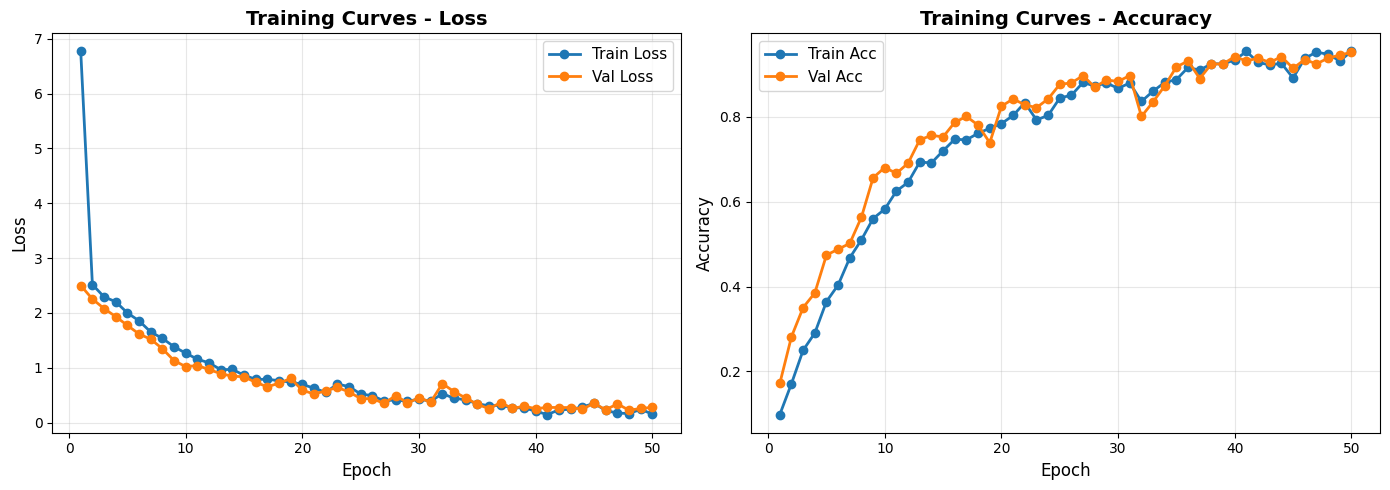

In [20]:
# Plot Training Curves
from model_util import plot_training_curves

plot_training_curves(history)

- We can see smooth convergences over the epochs with no sign of instability.

- Training and validation curves closely track each other, validating effective regularization, and no overfitting.


In [21]:
# Accuracy and loss on test set
from model_util import evaluate

test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = evaluate(model, test_loader, device)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.3898
Test Accuracy: 0.9386


- Test Accuracy: 93.86% shows strong generalization to completely unseen data

- Test Loss: 0.390 shows well-calibrated predictions

- Generalization gap of 1.33% (Validation: 95.19%, Test: 93.86%) shows Excellent model stability

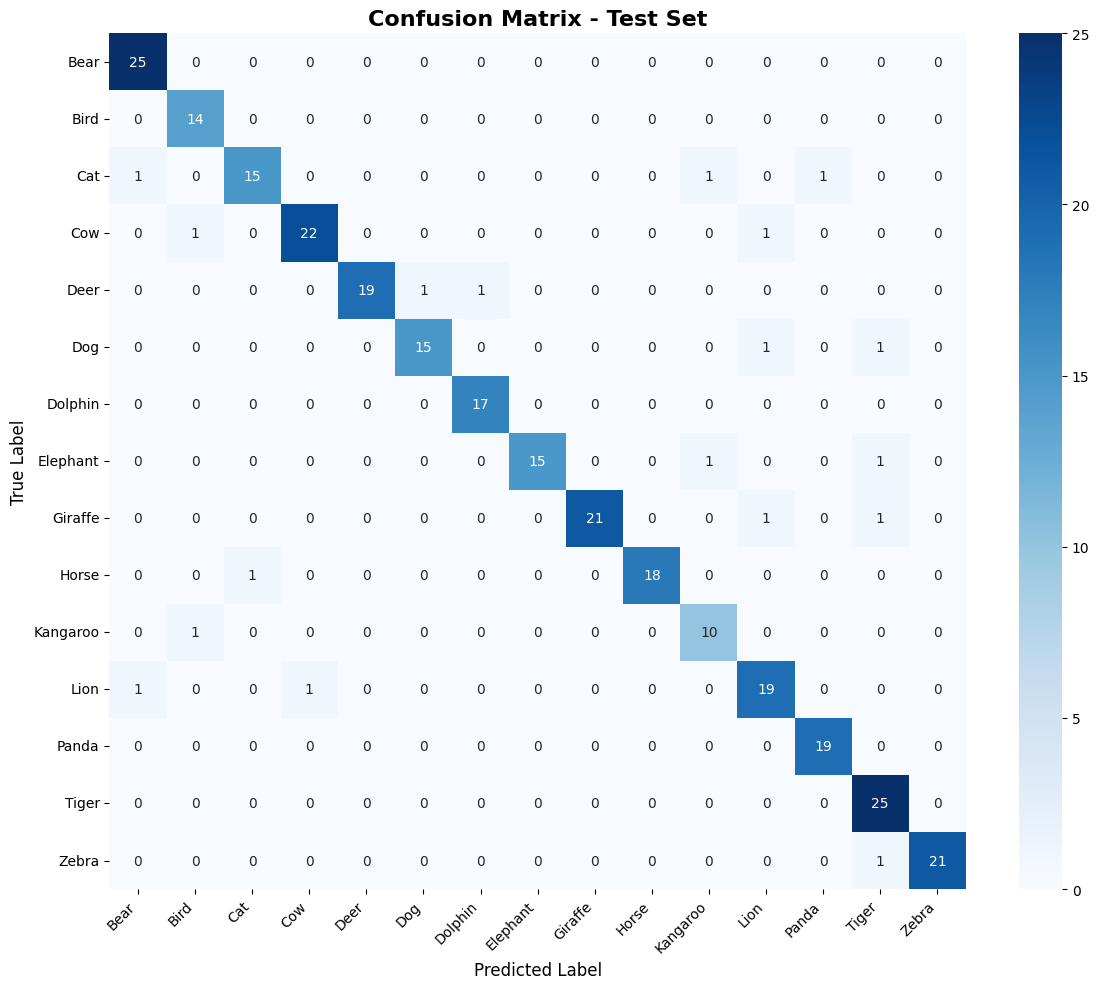

In [24]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, test_loader, device, class_names):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      _, pred = torch.max(output.data, 1)
      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(target.cpu().numpy())

  cm = confusion_matrix(all_labels, all_preds)

  plt.figure(figsize=(12, 10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
  plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
  plt.ylabel('True Label', fontsize=12)
  plt.xlabel('Predicted Label', fontsize=12)
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()
  return cm

class_names = dataset.classes
cm = plot_confusion_matrix(model, test_loader, device, class_names)

- Strong diagonal dominance: Most predictions align with true labels, indicating effective class discrimination across all 15 animal categories

- Minimal inter-class confusion: Off-diagonal elements are sparse, confirming the model learned distinct features for each animal type

- Balanced performance: No single class shows severe misclassification, suggesting uniform model capability across the dataset

### The Final Model Architecutre And Parameters Summary:

- Batch size 32

- LR 0.001

- Optimizer Adam

- Conv layers 32, 64, 128, 256

- Fc layers 512, 256

- Epochs 50

- Patience 10

- Weight decay 0.001

- Dropout 0.2


Also used: augmentation, and normalization on dataset.